<a href="https://colab.research.google.com/github/laughlavanya/lavanya/blob/main/Project_AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
## Binary classification
# classify email/SMS as apam(1) or notspam(0)
#-------------------------------------------
import pandas as pd
import numpy as np
import re
import string
#--------------------------------------------
#Step2: Load Dataset
#Download SMS spam collection Dataset
# save as spam.csv
#-------------------------------------------
df = pd.read_csv("spam (2).csv",encoding ='latin-1')
df = df [["v1","v2"]] # Corrected column names from v1, v2 to Category, Message
df.columns=["label","message"]
print("Dataset Shape:",df.shape)
print(df.head())
# convert labels to numeric
df["label"]=df["label"].map({"ham":0,"spam":1})
#---------------------------------------------------
# step 3: Clean Text
# --------------------------------------------------
def clean_text(text):
  text = text.lower()
  text = re.sub(r"http\S+","", text)
  text = re.sub(r"\d+","",text)
  text = text.translate(str.maketrans("","",string.punctuation)) #remove punctuation
  text = text.strip()
  return text
df["message"] = df["message"].apply(clean_text) # This line was incorrectly indented, making it part of the function.
print("\n Cleaned Sample:")
print((df["message"].head()))
#--------------------------------------------------------
# step 4: Convert text to TFIDF
#---------------------------------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["message"])
y = df["label"]
print("\n Feature Matrix Shape:",X.shape)
# Split data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
#------------------------------------------------------------
# step 5 : Train Logistic regression model
#-------------------------------------------------------------
from sklearn.linear_model import LogisticRegression # Changed sklearn.model_selection to sklearn.linear_model
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
print("\n Model Traing Completed:")
#------------------------------------------------------------
# Step 6 : Evaluate Model
#------------------------------------------------------------
from sklearn.metrics import accuracy_score, f1_score, classification_report # Corrected f1 to f1_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred) # Corrected y_predict to y_pred
f1 = f1_score(y_test,y_pred) # Corrected y_predict to y_pred and f1 to f1_score
print("Accuracy:",round(accuracy,4))
print("F1 Score:",round(f1,4)) # Corrected rounf to round
print("\n Detailed Classification Report:")
print(classification_report(y_test,y_pred))
#--------------------------------------------------
# Text with custom Input
#-------------------------------------------------
def predict_message(message):
  message=clean_text(message) # Corrected clean_test to clean_text
  message_vector = vectorizer.transform([message])
  prediction = model.predict(message_vector)
  return "Spam" if prediction == 1 else "Not Spam" # Corrected predicition to prediction
print("\nCustom prediction Example:")
print(predict_message("Congratulations! You won a free lottery ticket"))

Dataset Shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

 Cleaned Sample:
0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in  a wkly comp to win fa cup final...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: message, dtype: object

 Feature Matrix Shape: (5572, 8281)

 Model Traing Completed:
Accuracy: 0.9444
F1 Score: 0.7459

 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       965
           1       0.97      0.61      0.75       150

    

Adding graphs to the project

In [5]:
# step 1 import libraries

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix

In [6]:
# step 2 Load dataset
df=pd.read_csv('/content/spam (2).csv',encoding='latin-1')
df=df[['v1','v2']]
df.columns=["label","message"]
print("Dataset shape:",df.shape)
print(df.head())

Dataset shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [7]:
# convert labels to numeric
df["label"]=df["label"].map({"ham":0,"spam":1})

In [8]:
# step 3 Text cleaning
def clean_text(text):
  text=text.lower()
  text=re.sub(r"http\S+","",text)
  text=re.sub(r"\d+","",text)
  text=text.translate(str.maketrans("","",string.punctuation))
  text=text.strip()
  return text
df["message"]=df["message"].apply(clean_text)

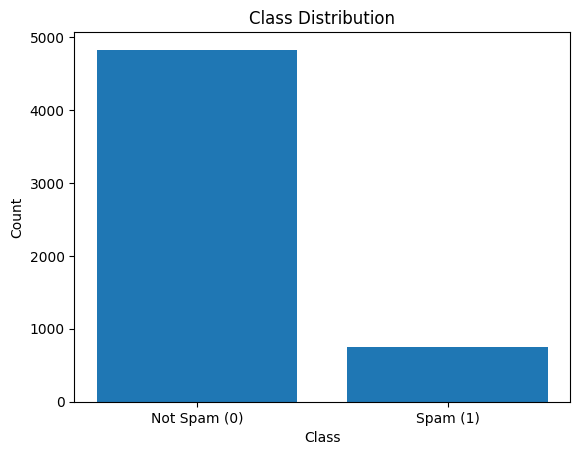

In [9]:
# graph 1: Bar Graph - Class Distribution
label_counts=df["label"].value_counts()
plt.figure()
plt.bar(["Not Spam (0)","Spam (1)"],label_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

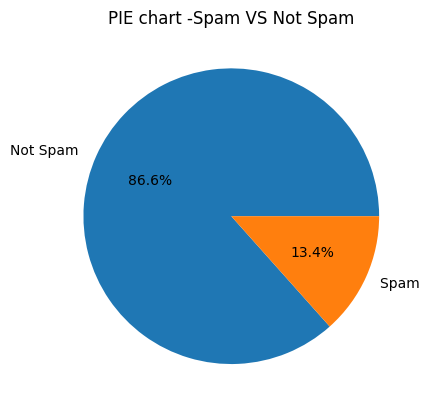

In [10]:
# graph 2 pie chart - class distribution
plt.figure()
plt.pie(label_counts.values,labels=["Not Spam ","Spam "],autopct="%1.1f%%")
plt.title("PIE chart -Spam VS Not Spam")
plt.show()

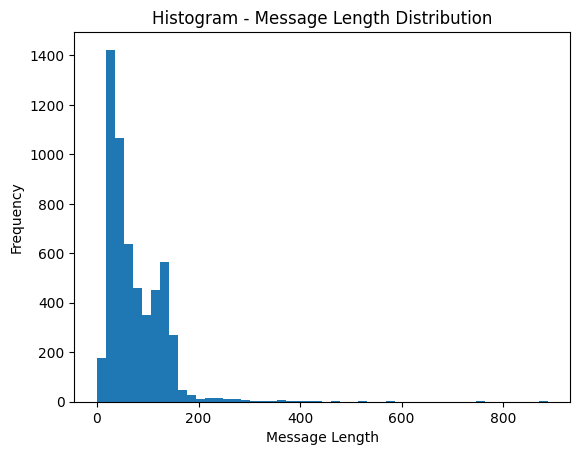

In [11]:
# Graph 3 : histogram - message length distribution
df["message_length"]=df['message'].apply(len)
plt.figure()
plt.hist(df["message_length"],bins=50)
plt.title("Histogram - Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

In [12]:
# step 4 : TF- IDF vectorization
vectorizer=TfidfVectorizer(stop_words="english")
x=vectorizer.fit_transform(df["message"])
y=df["label"]
print("Feature Matrix Shape:",x.shape)

Feature Matrix Shape: (5572, 8281)


In [13]:
# step 5: Train-Test Split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
# Step 6: train LOgistic Regression
model= LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
print("Model Training Completed")

Model Training Completed


In [15]:
# Step 7: Model Evaluation
y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("\n Model Evaluation")
print("Accuracy:",round(accuracy,4))
print("F1 Score:",round(f1,4))
print("\n Classification Report: \n")
print(classification_report(y_test,y_pred))


 Model Evaluation
Accuracy: 0.9444
F1 Score: 0.7459

 Classification Report: 

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       965
           1       0.97      0.61      0.75       150

    accuracy                           0.94      1115
   macro avg       0.96      0.80      0.86      1115
weighted avg       0.95      0.94      0.94      1115



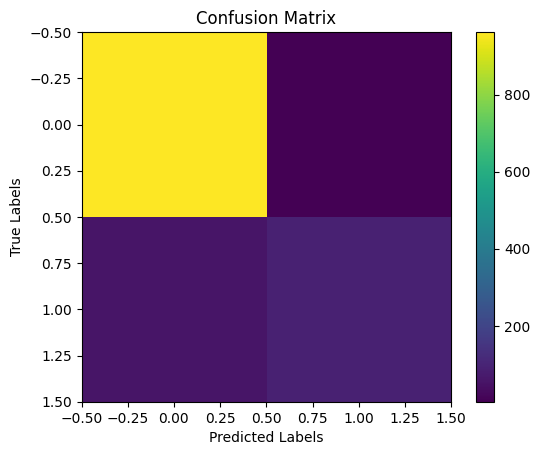

Confusion Matrix: 
 [[962   3]
 [ 59  91]]


In [16]:
#graph 4 : Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.colorbar()
plt.show()
print("Confusion Matrix: \n",cm)

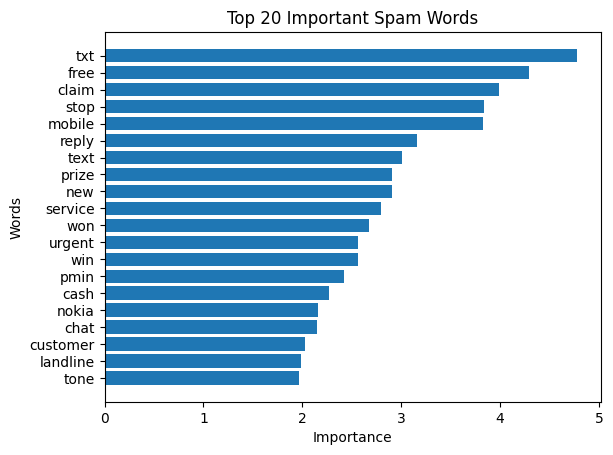

In [18]:
# Graph 5:Top 20 Important Spam Words
feature_names=np.array(vectorizer.get_feature_names_out())
coefficients=model.coef_[0]
top_indices=np.argsort(coefficients)[-20:]
top_words=feature_names[top_indices]
top_values=coefficients[top_indices]
plt.figure()
plt.barh(top_words,top_values)
plt.title("Top 20 Important Spam Words")
plt.xlabel("Importance")
plt.ylabel("Words")
plt.show()

In [19]:
# Step 8: Custom Prediction Function
def predict_message(message):
  message=clean_text(message)
  message_vector=vectorizer.transform([message])
  prediction=model.predict(message_vector)[0]
  return "spam" if prediction==1 else "Not Spam"
print("\n Custom Prediction Example:")
print(predict_message("Congratulations! You won a free lottery ticket"))


 Custom Prediction Example:
spam
